<a href="https://colab.research.google.com/github/sureshsaripalle2004/Task-1-Data-Cleaning/blob/main/Task1_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1: DATA CLEANING & PREPROCESSING

In [1]:
#Import Required Libraries
import pandas as pd              # for data handling
import numpy as np               # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns            # for visualization

In [3]:
#Upload Dataset
from google.colab import files
uploaded = files.upload()  # upload titanic.csv file

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [5]:
#Load Dataset
data = pd.read_csv("Titanic-Dataset.csv")

In [6]:
# Display first 5 rows
print("First 5 rows of dataset:")
print(data.head())

First 5 rows of dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [7]:
# Display dataset info
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [8]:
# Check missing values
print("\nMissing Values in each column:")
print(data.isnull().sum())


Missing Values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Handle Missing Values
# Fill missing values in 'Age' column with mean
data['Age'].fillna(data['Age'].mean(), inplace=True)
# Fill missing values in 'Embarked' column with mode (most frequent value)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
# Drop 'Cabin' column because it has too many missing values
data.drop('Cabin', axis=1, inplace=True)
print("\nMissing Values after handling:")
print(data.isnull().sum())


Missing Values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_14286/4261401702.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipykernel_14286/4261401702.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [10]:
# Convert Categorical Data to Numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Convert 'Sex' column (male/female → 0/1)
data['Sex'] = le.fit_transform(data['Sex'])
# Convert 'Embarked' column (C/Q/S → numbers)
data['Embarked'] = le.fit_transform(data['Embarked'])
print("\nData after encoding categorical variables:")
print(data.head())


Data after encoding categorical variables:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked  
0         A/5 21171   7.2500         2  
1          PC 17599  71.2833         0  
2  STON/O2. 3101282   7.9250         2  
3            113803  53.1000         2  
4            373450   8.0500         2  


In [11]:
# Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Scale numerical columns (Age and Fare)
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])
print("\nData after scaling:")
print(data.head())


Data after scaling:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    1 -0.592481      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  0.638789      1   
2                             Heikkinen, Miss. Laina    0 -0.284663      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.407926      1   
4                           Allen, Mr. William Henry    1  0.407926      0   

   Parch            Ticket      Fare  Embarked  
0      0         A/5 21171 -0.502445         2  
1      0          PC 17599  0.786845         0  
2      0  STON/O2. 3101282 -0.488854         2  
3      0            113803  0.420730         2  
4      0            373450 -0.486337         2  

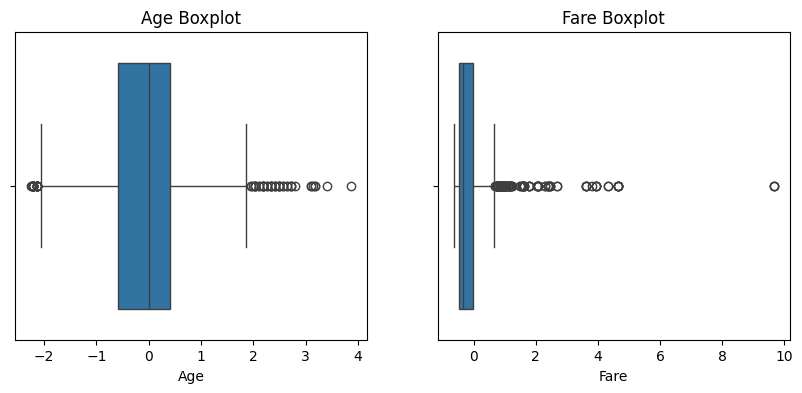

In [12]:
# Visualize Outliers using Boxplots
plt.figure(figsize=(10,4))
# Boxplot for Age
plt.subplot(1,2,1)
sns.boxplot(x=data['Age'])
plt.title("Age Boxplot")
# Boxplot for Fare
plt.subplot(1,2,2)
sns.boxplot(x=data['Fare'])
plt.title("Fare Boxplot")
plt.show()



In [13]:
# Remove Outliers using IQR Method
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Remove outliers
data = data[(data['Fare'] >= lower_bound) & (data['Fare'] <= upper_bound)]
print("\nData after removing outliers:")
print(data.shape)


Data after removing outliers:
(775, 11)


In [14]:
# Final Clean Dataset Check
print("\nFinal Missing Values:")
print(data.isnull().sum())
print("\nFinal Cleaned Dataset Preview:")
print(data.head())




Final Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Final Cleaned Dataset Preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    1 -0.592481      1      0   
2                        Heikkinen, Miss. Laina    0 -0.284663      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.407926      1      0   
4                      Allen, Mr. William Henry    1  0.407926      0      0   
5                              Moran, Mr. James    1  0.000000      0      0   

             Ticket      Fare  Embarked  
0    

In [15]:

# Save cleaned dataset as CSV
data.to_csv("cleaned_titanic.csv", index=False)
# Download file in Colab
files.download("cleaned_titanic.csv")
print("\n Data Cleaning Completed Successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Data Cleaning Completed Successfully!
